<a href="https://colab.research.google.com/github/fox-n/ML_course_homeworks/blob/main/Copy_of_HW_2_1_%D0%9F%D0%BE%D0%B1%D1%83%D0%B4%D0%BE%D0%B2%D0%B0_%D0%BB%D1%96%D0%BD%D1%96%D0%B9%D0%BD%D0%BE%D1%97_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%97_%D0%B7%D0%B0_%D0%BE%D0%B4%D0%BD%D0%BE%D1%8E_%D0%BE%D0%B7%D0%BD%D0%B0%D0%BA%D0%BE%D1%8E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

!pip install scikit-learn --quiet
from sklearn.linear_model import LinearRegression

!pip -q install gdown
import gdown


In [137]:
url_application_data_csv_zip = "https://drive.google.com/file/d/1ujV3Ddy6TYDW__pxXPMXhK9us21xOSVw/view?usp=sharing"
gdown.download(url_application_data_csv_zip, "medical-charges.csv", fuzzy=True)

medical_df = pd.read_csv("medical-charges.csv")

Downloading...
From: https://drive.google.com/uc?id=1ujV3Ddy6TYDW__pxXPMXhK9us21xOSVw
To: /content/medical-charges.csv
100%|██████████| 55.6k/55.6k [00:00<00:00, 2.68MB/s]


In [138]:
non_smoker_df = medical_df[medical_df.smoker == 'no']


# Метод МНК з numpy

In [139]:
def normal_equations(X,y):
    """Computes the closed-form solution to linear regression"""
    theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return theta

In [171]:
y = non_smoker_df.charges #вектор спостережуваних значень
X = non_smoker_df.age
X_with_intercept = np.c_[np.ones((X.shape[0], 1)), X]

In [141]:
MNK_coefs = normal_equations(X_with_intercept, y)

In [142]:
predictions_MNK = np.dot(X_with_intercept, MNK_coefs)

In [143]:
print(f'Коефіцієнти моделі: {MNK_coefs}\n')


Коефіцієнти моделі: [-2091.42055657   267.24891283]



In [144]:
def model_estimation(design_matrix, actual_values, predicted_values):
  """Function will help to vizualize results of model prediction and
      calculate quality metrics of the model"""
  #Візуальна оцінка роботи моделі

  plt.plot(design_matrix, predicted_values, color = 'r', alpha=0.9);
  plt.scatter(design_matrix, actual_values, color = 'b', s=8, alpha=0.8);
  plt.xlabel('Age');
  plt.ylabel('Charges')
  plt.legend(['Estimate', 'Actual']);
  plt.grid(True)
  plt.show()

  #Розрахунок метрик якості моделей

  SSR = np.sum(np.square(actual_values - predicted_values))
  TSS = np.sum(np.square(actual_values - np.mean(actual_values)))
  r2 = 1 - SSR/TSS

  rmse = np.sqrt(np.mean((np.square(predicted_values - actual_values))))
  mae = (np.sum(np.abs(actual_values - predicted_values)))/len(design_matrix)

  print(f"R² score: {r2:.2f}\n")
  print(f"Root Mean Squared Error: {rmse:.2f}\n")
  print(f"Mean Absolute Error: {mae:.2f}\n")

  print(f"mean: {(np.mean(y)):.2f}\n")
  print(f"std: {(np.std(y)):.2f}\n")
  print(f"min: {(np.min(y)):.2f}\n")


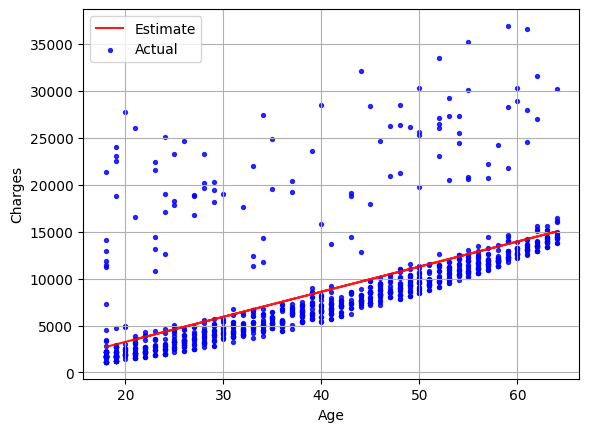

R² score: 0.39

Root Mean Squared Error: 4662.51

Mean Absolute Error: 2580.52

mean: 8434.27

std: 5990.96

min: 1121.87



In [145]:
model_estimation(X, y, predictions_MNK)

Спостереження: значення rmse, яке я отримала завдяки застосуванню МНК (4662.51)є дуже близьким до того, яке я підібрала вручну (4790.15), хоча коефіцієнти моделі інакші. Метрики якості моделі показують, що вона добре спрацювала.

#Full-Batch градієнтний спуск з numpy

In [193]:
# Градієнтний спуск
def full_batch_gradient_descent(X, y, lr=0.01, epochs=100):
    m, b = 0.0, 0.0  # Початкові параметри
    n = len(y)
    errors = []
    for _ in range(epochs):
        y_pred = m * X + b
        error = y_pred - y
        errors.append(sum(error**2))
        m_gradient = (2/n) * np.dot(error, X)
        b_gradient = (2/n) * np.sum(error)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
    return m, b, errors

m, b, errors = full_batch_gradient_descent(X, y, lr=1e-4, epochs=1000)
predictions_fbgd = m * X + b


In [194]:
print(f'Коефіцієнти моделі:\n m = {m}, b = {b}\n')

Коефіцієнти моделі:
 m = 221.1045843794301, b = -41.98126853149978



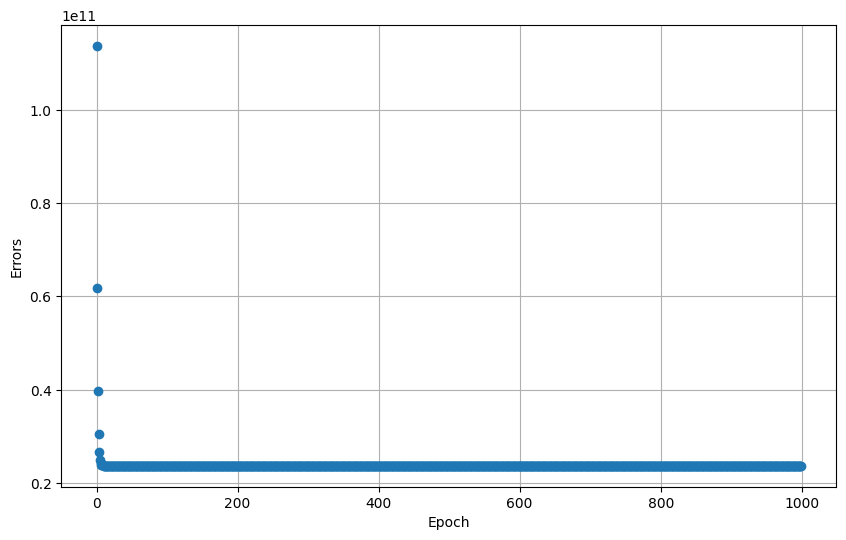

In [195]:
#графік помилки в залежності від ітерації

plt.figure(figsize=(10, 6))
plt.plot(errors, 'o');
plt.xlabel('Epoch')
plt.ylabel('Errors')
plt.grid(True)
plt.show()

In [147]:
def try_several_lr(design_matrix, actual_values, lr, epochs):

  """function calculates coefficients for model using full batch gradient descent
      with a given learing rate and epochs number
      and adds vizualize every new try
  """
  m, b, errors = full_batch_gradient_descent(design_matrix, actual_values, lr=lr, epochs=epochs)
  predictions_fbgd = m * X + b

  #Розрахунок метрик якості моделей

  predicted_values = predictions_fbgd

  SSR = np.sum(np.square(actual_values - predicted_values))
  TSS = np.sum(np.square(actual_values - np.mean(actual_values)))
  r2 = 1 - SSR/TSS

  rmse = np.sqrt(np.mean((np.square(predicted_values - actual_values))))
  mae = (np.sum(np.abs(actual_values - predicted_values)))/len(design_matrix)

  print(f"R² score: {r2:.2f}\n")
  print(f"Root Mean Squared Error: {rmse:.2f}\n")
  print(f"Mean Absolute Error: {mae:.2f}\n")

  print(f"mean: {(np.mean(y)):.2f}\n")
  print(f"std: {(np.std(y)):.2f}\n")
  print(f"min: {(np.min(y)):.2f}\n")


  return

In [148]:
try_several_lr(X, y, 1e-3, 1000)

R² score: 1.00

Root Mean Squared Error: nan

Mean Absolute Error: 0.00

mean: 8434.27

std: 5990.96

min: 1121.87



/tmp/ipython-input-4167576599.py:12: RuntimeWarning: invalid value encountered in scalar subtract
  m = m - lr * m_gradient


In [149]:
try_several_lr(X, y, 1e-4, 1000) # з цим lr - найменша rsme

R² score: 0.38

Root Mean Squared Error: 4713.25

Mean Absolute Error: 2803.85

mean: 8434.27

std: 5990.96

min: 1121.87



In [150]:
try_several_lr(X, y, 1e-5, 1000)

R² score: 0.38

Root Mean Squared Error: 4715.35

Mean Absolute Error: 2809.44

mean: 8434.27

std: 5990.96

min: 1121.87



In [151]:
try_several_lr(X, y, 1e-6, 1000)

R² score: 0.38

Root Mean Squared Error: 4723.65

Mean Absolute Error: 2673.75

mean: 8434.27

std: 5990.96

min: 1121.87



In [152]:
try_several_lr(X, y, 1e-7, 1000)

R² score: -0.79

Root Mean Squared Error: 8020.83

Mean Absolute Error: 5873.35

mean: 8434.27

std: 5990.96

min: 1121.87



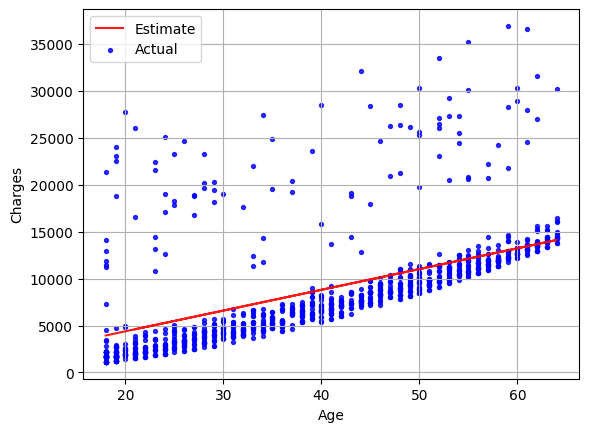

R² score: 0.38

Root Mean Squared Error: 4713.25

Mean Absolute Error: 2803.85

mean: 8434.27

std: 5990.96

min: 1121.87



In [153]:
model_estimation(X, y, predictions_fbgd)

Спостереження:
Я спробувала більше ніж 3 різних lr. Найменшу похибка вийшла при lr = 1e-4, тому я підставила в модель саме таку швидкість і для неї вже зробіла визуализацію та розрахувала фінальні метрики якості моделі.
lr <= 1e-3 був завеликим, метод не працював. При виборі lr >= 1e-7 модель не встигала навчитись.
Якщо порівнювати результат з МНК, то МНК показав кращий результат.

#З scikit-learn.LinearRegression (Non-smokers/Age)


In [174]:
X_s = X.to_frame()

In [181]:
lin_reg = LinearRegression()
lin_reg.fit(X_s, y, None)
lin_reg.coef_, lin_reg.intercept_


(array([267.24891283]), np.float64(-2091.4205565650864))

In [182]:
print(f'Коефіцієнти моделі:\n lin_reg.coef = {lin_reg.coef_}, lin_reg.intercept = {lin_reg.intercept_}\n')

Коефіцієнти моделі:
 lin_reg.coef = [267.24891283], lin_reg.intercept = -2091.4205565650864



In [185]:
predictions_sklearn = lin_reg.predict(X_s)

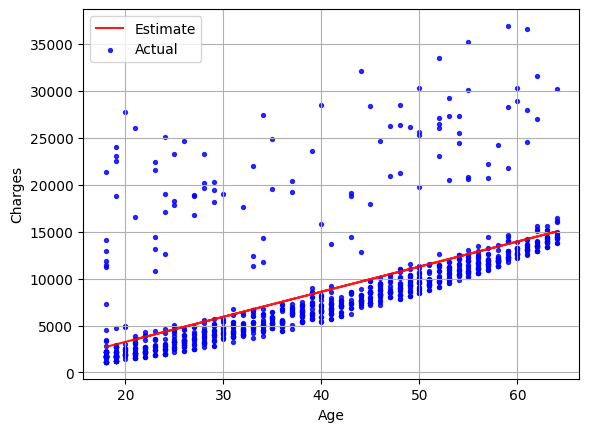

R² score: 0.39

Root Mean Squared Error: 4662.51

Mean Absolute Error: 2580.52

mean: 8434.27

std: 5990.96

min: 1121.87



In [186]:
model_estimation(X_s, y, predictions_sklearn)

Спостереження: Розрахунок за допомогою scikit-learn.LinearRegression дав помилку приблизно однаково з ручним розрахунком МНК, що очикувано, бо під капотом він рахує МНК

# Візуалізація порівняння результатів

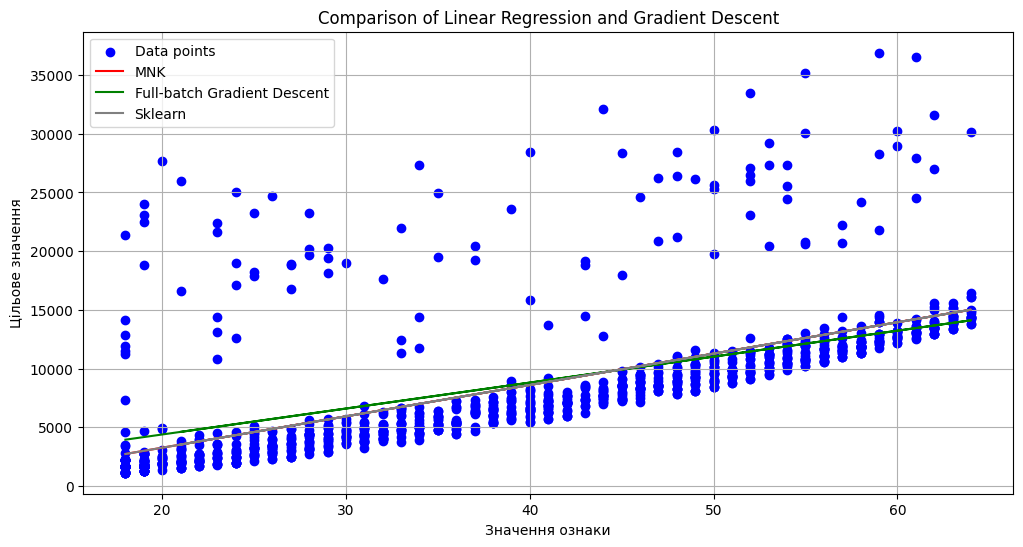

In [187]:
# Візуалізація порівняння результатів
plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, predictions_MNK, color='red', label='MNK')
plt.plot(X, predictions_fbgd, color='green', label='Full-batch Gradient Descent')
plt.plot(X_s, predictions_sklearn, color='grey', label='Sklearn')
plt.title('Comparison of Linear Regression and Gradient Descent')
plt.xlabel('Значення ознаки')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()


Висновки: Результати моделей доволі близькі, для MNK та Sklearn вони накладаються, що очікувано. MNK показує себе в даному випадку більш ефективним. Результати вийшли близькі до попереднього підбору вручну.

#З scikit-learn.LinearRegression (Smokers/Age)


 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [198]:
smoker_df = medical_df[medical_df.smoker == 'yes']

In [200]:
y_smoker = smoker_df.charges #вектор спостережуваних значень
X_smoker = smoker_df.age

In [201]:
X_smoker_s = X_smoker.to_frame()

In [202]:
lin_reg = LinearRegression()
lin_reg.fit(X_smoker_s, y_smoker, None)
lin_reg.coef_, lin_reg.intercept_

(array([305.23760211]), np.float64(20294.128126915966))

In [203]:
print(f'Коефіцієнти моделі:\n lin_reg.coef = {lin_reg.coef_}, lin_reg.intercept = {lin_reg.intercept_}\n')

Коефіцієнти моделі:
 lin_reg.coef = [305.23760211], lin_reg.intercept = 20294.128126915966



In [205]:
smoker_predictions_sklearn = lin_reg.predict(X_smoker_s)

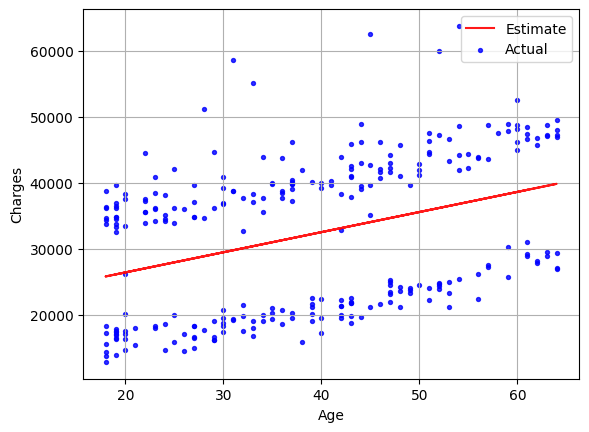

R² score: 0.14

Root Mean Squared Error: 10711.00

Mean Absolute Error: 10097.80

mean: 8434.27

std: 5990.96

min: 1121.87



In [206]:
model_estimation(X_smoker_s, y_smoker, smoker_predictions_sklearn)

Висновки: Модель вийшла дуже поганою, очевидно Вік для курців не є впливовою ознакою для оцінки виплат. Я би не радила використовувати цю модель в компанії.